In [1]:
# Import libraries
import numpy as np
import glob
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import os

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ["TF_PROFILER_DISABLE_GPU"] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras import layers, models, optimizers

# Months
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Check GPUs
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Is GPU used for computation?", tf.config.list_physical_devices('GPU') != [])

Num GPUs Available:  0
Is GPU used for computation? False


2025-08-15 13:22:40.645257: E tensorflow/stream_executor/cuda/cuda_driver.cc:328] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
# Configuration
region = 'Global'
no_E3SM = True
SAT_SLP = False
m = 4  # March = 2, April = 3, May = 4

# Check statement
print('Region:', region, '\nMonth:', months[m])

Region: Global 
Month: May


In [3]:
def weighted_spatial(data_array, lats):
    '''Compute weighted spatial averages over lat/lon dims.'''
    weights = np.cos(np.deg2rad(lats))
    weighted_data = data_array * weights[:, np.newaxis]
    weighted_sum = np.nansum(weighted_data)
    denom = np.nansum(weights) * data_array.shape[1]
    return weighted_sum / denom


def get_data(paths):
    '''Load data efficiently.'''
    X_MAPS, Y_DATA, model_names = [], [], []
    for path in paths:
        model_name = os.path.splitext(os.path.basename(path))[0]
        model_names.append(model_name)

        with xr.open_dataset(path, chunks={'time': 100}) as ds:
            ds_sel = ds.sel(period=slice(1900, 2050))
            if SAT_SLP:
                sat = ds_sel.X_SAT_SLP[..., 0].values
                slp = ds_sel.X_SAT_SLP[..., 1].values
                X_maps = np.stack([sat, slp], axis=-1)
            else:
                X_maps = ds_sel.X_SAT_SLP[..., 0].values

            Y_data = ds_sel.Y_I_E_SUM.values

        X_MAPS.append(X_maps)
        Y_DATA.append(Y_data)

    return X_MAPS, Y_DATA, model_names


def compute_actual_trends(obs_maps):
    '''Compute observed actual trends.'''
    lats = np.arange(-88.75, 88.751, 2.5)
    shape = np.shape(obs_maps)
    actual_trends_all_obs = np.empty((shape[0], shape[1]))

    for combo in range(shape[0]):
        for month in range(shape[1]):
            if SAT_SLP:
                actual_trends_all_obs[combo, month] = weighted_spatial(obs_maps[combo, month, :, :, 0], lats)
            else:
                actual_trends_all_obs[combo, month] = weighted_spatial(obs_maps[combo, month, :], lats)

    print(f'Observed {months[m]} mean: {np.nanmean(actual_trends_all_obs[:, m], axis=0):.3f} K/dec')

    return actual_trends_all_obs, obs_maps


def create_CNN(input_shape):
    '''Initialize CNN.'''
    inpt = layers.Input(shape=input_shape)

    # Convolutional layer
    conv = layers.Conv2D(16, (3, 7), padding='same', activation='relu')(inpt)
    pool = layers.MaxPooling2D(1)(conv)
    drop = layers.Dropout(0.5)(pool)

    # Flatten and output layer
    flat = layers.Flatten()(drop)
    out = layers.Dense(2)(flat)

    model = models.Model(inputs=inpt, outputs=out)
    return model


def prepare_data(splice_X, splice_Y, hist_X, hist_Y, cv, m):
    '''Bootstrap 10 ensemble members to train on from models with more than 10 members.'''

    splice_X_10ens, splice_Y_10ens = [], []
    for idx in range(len(splice_X)):
        random_idxs = tf.random.shuffle(tf.range(tf.shape(splice_X[idx])[0]))[:10]
        splice_X_10ens.append(tf.gather(splice_X[idx][:, :, m], random_idxs))
        splice_Y_10ens.append(tf.gather(splice_Y[idx][:, :, m], random_idxs))

    hist_X_10ens, hist_Y_10ens = [], []
    for idx in range(len(hist_X)):
        random_idxs = tf.random.shuffle(tf.range(tf.shape(hist_X[idx])[0]))[:10]
        hist_X_10ens.append(tf.gather(hist_X[idx][:, :, m], random_idxs))
        hist_Y_10ens.append(tf.gather(hist_Y[idx][:, :, m], random_idxs))

    # Delete the specified index and concatenate, specify for E3SM-2-0
    if no_E3SM:
        if cv == 0:
            X_train_spliced = tf.concat([splice_X_10ens[i] for i in range(tf.shape(splice_X_10ens)[0])], axis=0)
            Y_train_spliced = tf.concat([splice_Y_10ens[i] for i in range(tf.shape(splice_Y_10ens)[0])], axis=0)
        else:
            X_train_spliced = tf.concat([splice_X_10ens[i] for i in range(tf.shape(splice_X_10ens)[0]) if i != cv], axis=0)
            Y_train_spliced = tf.concat([splice_Y_10ens[i] for i in range(tf.shape(splice_Y_10ens)[0]) if i != cv], axis=0)
    else:
        X_train_spliced = tf.concat([splice_X_10ens[i] for i in range(tf.shape(splice_X_10ens)[0]) if i != cv], axis=0)
        Y_train_spliced = tf.concat([splice_Y_10ens[i] for i in range(tf.shape(splice_Y_10ens)[0]) if i != cv], axis=0)

    # Concatenate the hist tensors
    X_train_hist = tf.concat(hist_X_10ens, axis=0)
    Y_train_hist = tf.concat(hist_Y_10ens, axis=0)

    # Reshape to flatten first two dims (ensemble + time)
    def reshape_flat(tensor):
        shape = tf.shape(tensor)
        new_shape = tf.concat([[-1], shape[2:]], axis=0)
        return tf.reshape(tensor, new_shape)

    X_train_spliced = reshape_flat(X_train_spliced)
    X_train_hist = reshape_flat(X_train_hist)

    Y_train_spliced = tf.reshape(Y_train_spliced, [-1, tf.shape(Y_train_spliced)[2]])
    Y_train_hist = tf.reshape(Y_train_hist, [-1, tf.shape(Y_train_hist)[2]])

    X_train = tf.concat([X_train_spliced, X_train_hist], axis=0)
    Y_train = tf.concat([Y_train_spliced, Y_train_hist], axis=0)

    return X_train, Y_train

In [ ]:
# === Load observation data ===
sat_paths = np.sort(glob.glob('/glade/work/skygale/training-data/monthly/observations/sat/*.nc'))[::-1]
slp_paths = glob.glob('/glade/work/skygale/training-data/monthly/observations/slp/*')

obs_maps = []
if SAT_SLP:
    for sat_path in sat_paths:
        X_maps_sat = xr.load_dataset(sat_path).DATA
        for slp_path in slp_paths:
            X_maps_slp = xr.load_dataset(slp_path).DATA
            combined = np.stack([X_maps_sat.values, X_maps_slp.values], axis=-1)
            obs_maps.append(combined)
else:
    for sat_path in sat_paths:
        X_maps_sat = xr.load_dataset(sat_path).DATA
        obs_maps.append(X_maps_sat)

obs_maps = np.array(obs_maps)
actual_trends_obs_means, obs_maps = compute_actual_trends(obs_maps)

# === Load simulated data ===
spliced_path = '/glade/work/skygale/training-data/monthly/spliced/'
hist_path = '/glade/work/skygale/training-data/monthly/hist/'
spliced = glob.glob(spliced_path+region.lower()+'/*')
hist = glob.glob(hist_path+region.lower()+'/*')

# === Remove unwanted files ===
spliced = [model for model in spliced if 'OthersAllEM.nc' not in model]
hist = [model for model in hist if 'OthersAllEM.nc' not in model]

# === Store data ===
splice_X, splice_Y, model_names_spliced_old = get_data(spliced)
hist_X, hist_Y, model_names_hist = get_data(hist)

# === Reorganize models by warming indices ===
models_reorganized = [
    'E3SM-2-0',
    'CanESM5',
    'MIROC6',
    'MPI-ESM1-2-LR',
    'IPSL-CM6A-LR',
    'ACCESS-ESM1-5',
    'CESM2',
    'CESM2_SMBB'
]

ranked_warming_indices = [model_names_spliced_old.index(name) for name in models_reorganized]
splice_X_array = [splice_X[i] for i in ranked_warming_indices]
splice_Y_array = [splice_Y[i] for i in ranked_warming_indices]
model_names_spliced = [model_names_spliced_old[i] for i in ranked_warming_indices]

# === Convert observations into PyTorch tensors ===
splice_X, splice_Y = [], []
[splice_X.append(tf.convert_to_tensor(splice_X_array[i])) for i in range(len(splice_X_array))]
[splice_Y.append(tf.convert_to_tensor(splice_Y_array[i])) for i in range(len(splice_Y_array))]
obs_maps = tf.convert_to_tensor(obs_maps)

# === Check data we are using for training ===
print('\n')
for i, splice in enumerate(splice_X):
    print(i+1, np.shape(splice), model_names_spliced[i])

print('\n')
for i, splice in enumerate(splice_Y):
    print(i+1, np.shape(splice), model_names_spliced[i])

# Remove E3SMv2 from training data
if no_E3SM:
    print('\n==> E3SM not included in training data.')

    splice_X_cut = splice_X[1:]
    splice_Y_cut = splice_Y[1:]
    model_names_spliced_cut = model_names_spliced[1:]

    print('\n')
    for i, splice in enumerate(splice_X_cut):
        print(i+1, np.shape(splice), model_names_spliced_cut[i])

    print('\n')
    for i, splice in enumerate(splice_Y_cut):
        print(i+1, np.shape(splice), model_names_spliced_cut[i])
else:
    print('\n==> E3SM included in training data.')

print('\nDone!')

Observed May mean: 0.172 K/dec


In [25]:
# Create arrays for which to store result
cv_preds_and_vals = []
cv_obs = []
cv_mse = []
prediction_error = []

# Main training loop
Xscale = MinMaxScaler()
Yscale = MinMaxScaler()

with tf.device('/GPU:0'):

    # Loop through each large ensemble we test on
    for cv in range(len(splice_X)):
        print('Cross Validation:', model_names_spliced[cv])

        cv_preds_and_vals_one_randomization = []
        cv_obs_one_randomization = []

        # Create the CNN 50 times to cut noise from random initializations
        for randomization in range(50):
            # Clear previous models from memory and avoid GPU memory bloat
            tf.keras.backend.clear_session()

            # Define training data
            X_train, Y_train = prepare_data(splice_X_cut, splice_Y_cut, hist_X, hist_Y, cv, m)

            # Reshape training data for CNN
            X_train_reshaped = tf.reshape(X_train, (tf.shape(X_train)[0], -1))
            Y_train_reshaped = Y_train[:, :2]

            # Define testing data
            X_test = splice_X[cv][:, -6, m]
            X_test_reshaped = tf.reshape(X_test, (tf.shape(X_test)[0], -1))
            Y_test_reshaped = splice_Y[cv][:, -6, m, :2]

            # Scale training and testing data
            Xscale.fit(X_train_reshaped.numpy())
            Yscale.fit(Y_train_reshaped.numpy())
            X_train_scaled = Xscale.transform(X_train_reshaped.numpy())
            X_test_scaled = Xscale.transform(X_test_reshaped.numpy())
            Y_train_scaled = Yscale.transform(Y_train_reshaped.numpy())

            # Put data back into sample x map x channel shape
            if SAT_SLP:
                X_train_scaled = tf.reshape(X_train_scaled, tf.shape(X_train))
                X_test_scaled = tf.reshape(X_test_scaled, tf.shape(X_test))
            else:
                X_train_scaled = tf.reshape(X_train_scaled, (*X_train.shape[:3], 1))
                X_test_scaled = tf.reshape(X_test_scaled, (*X_test.shape[:3], 1))

            # Create the model
            model = create_CNN(input_shape=X_train_scaled.shape[1:])
            model.compile(loss='mse', optimizer=optimizers.Adam(learning_rate=1e-4))

            # Fit the model with validation data
            model.fit(
                X_train_scaled,
                Y_train_scaled,
                epochs=10,
                verbose=0,
                batch_size=32,
                shuffle=True
            )

            # Make predictions on testing data
            Y_pred_scaled = model.predict(X_test_scaled)
            Y_preds_unscaled = Yscale.inverse_transform(Y_pred_scaled)

            # Reshape prediction and actual values
            Y_pred = tf.transpose(Y_preds_unscaled).numpy().tolist()
            Y_test_one_model = tf.transpose(Y_test_reshaped).numpy().tolist()

            # Append sum values to prediction and actual values
            Y_pred.append(np.nansum(Y_pred, axis=0))
            Y_test_one_model.append(np.nansum(Y_test_one_model, axis=0))
            cv_preds_and_vals_one_randomization.append([tf.transpose(Y_pred), tf.transpose(Y_test_one_model)])

            # Prepare predicting data
            obs_map = obs_maps[:, m]
            X_obs_reshaped = tf.reshape(obs_map, (tf.shape(obs_map)[0], -1))

            # Make predictions on observations
            X_obs_scaled = Xscale.transform(X_obs_reshaped.numpy())
            X_obs_map_scaled = tf.reshape(X_obs_scaled, tf.shape(obs_map))
            obs_Y_pred_scaled = model.predict(X_obs_map_scaled)

            # Reshape observation prediction values
            obs_Y_pred_unscaled = Yscale.inverse_transform(obs_Y_pred_scaled)
            Y_obs = tf.transpose(obs_Y_pred_unscaled).numpy().tolist()
            Y_obs.append(np.nansum(Y_obs, axis=0))
            cv_obs_one_randomization.append(Y_obs)

        # Find mean prediction for the current cross-validation fold
        mean_of_randomizations_val = tf.reduce_mean(cv_preds_and_vals_one_randomization, axis=0).numpy()
        mean_of_randomizations_obs = tf.reduce_mean(cv_obs_one_randomization, axis=0).numpy()
        error = mean_of_randomizations_val[0] - mean_of_randomizations_val[1]
        prediction_error.append(error)
        mse_of_cv = [tf.reduce_mean(tf.square(error[:, i])).numpy() for i in range(3)]

        # Append to arrays of all cvs
        cv_preds_and_vals.append(mean_of_randomizations_val)
        cv_obs.append(mean_of_randomizations_obs)
        cv_mse.append(mse_of_cv)

# Save cross validation predicted values
for i in range(len(model_names_spliced)):
    np.save('./preds_and_vals/'+months[m]+'/'+region.lower()+'_'+str(model_names_spliced[i])+'.npy', np.array(cv_preds_and_vals[i]))

# Save observation predicted values
np.save('./preds_and_vals/'+months[m]+'/'+region+'_obs.npy', np.array(cv_obs))

print('Done!')

Cross Validation: E3SM-2-0
Cross Validation: CanESM5
Cross Validation: MIROC6
Cross Validation: MPI-ESM1-2-LR
Cross Validation: IPSL-CM6A-LR
Cross Validation: ACCESS-ESM1-5
Cross Validation: CESM2
Cross Validation: CESM2_SMBB
Done!


Sigma_obs: 0.0019391472
Sigma_CNN: 0.023506183
Sigma_obs: 0.0016468555
Sigma_CNN: 0.030537726
Sigma_obs: 0.0034586869
Sigma_CNN: 0.011178993


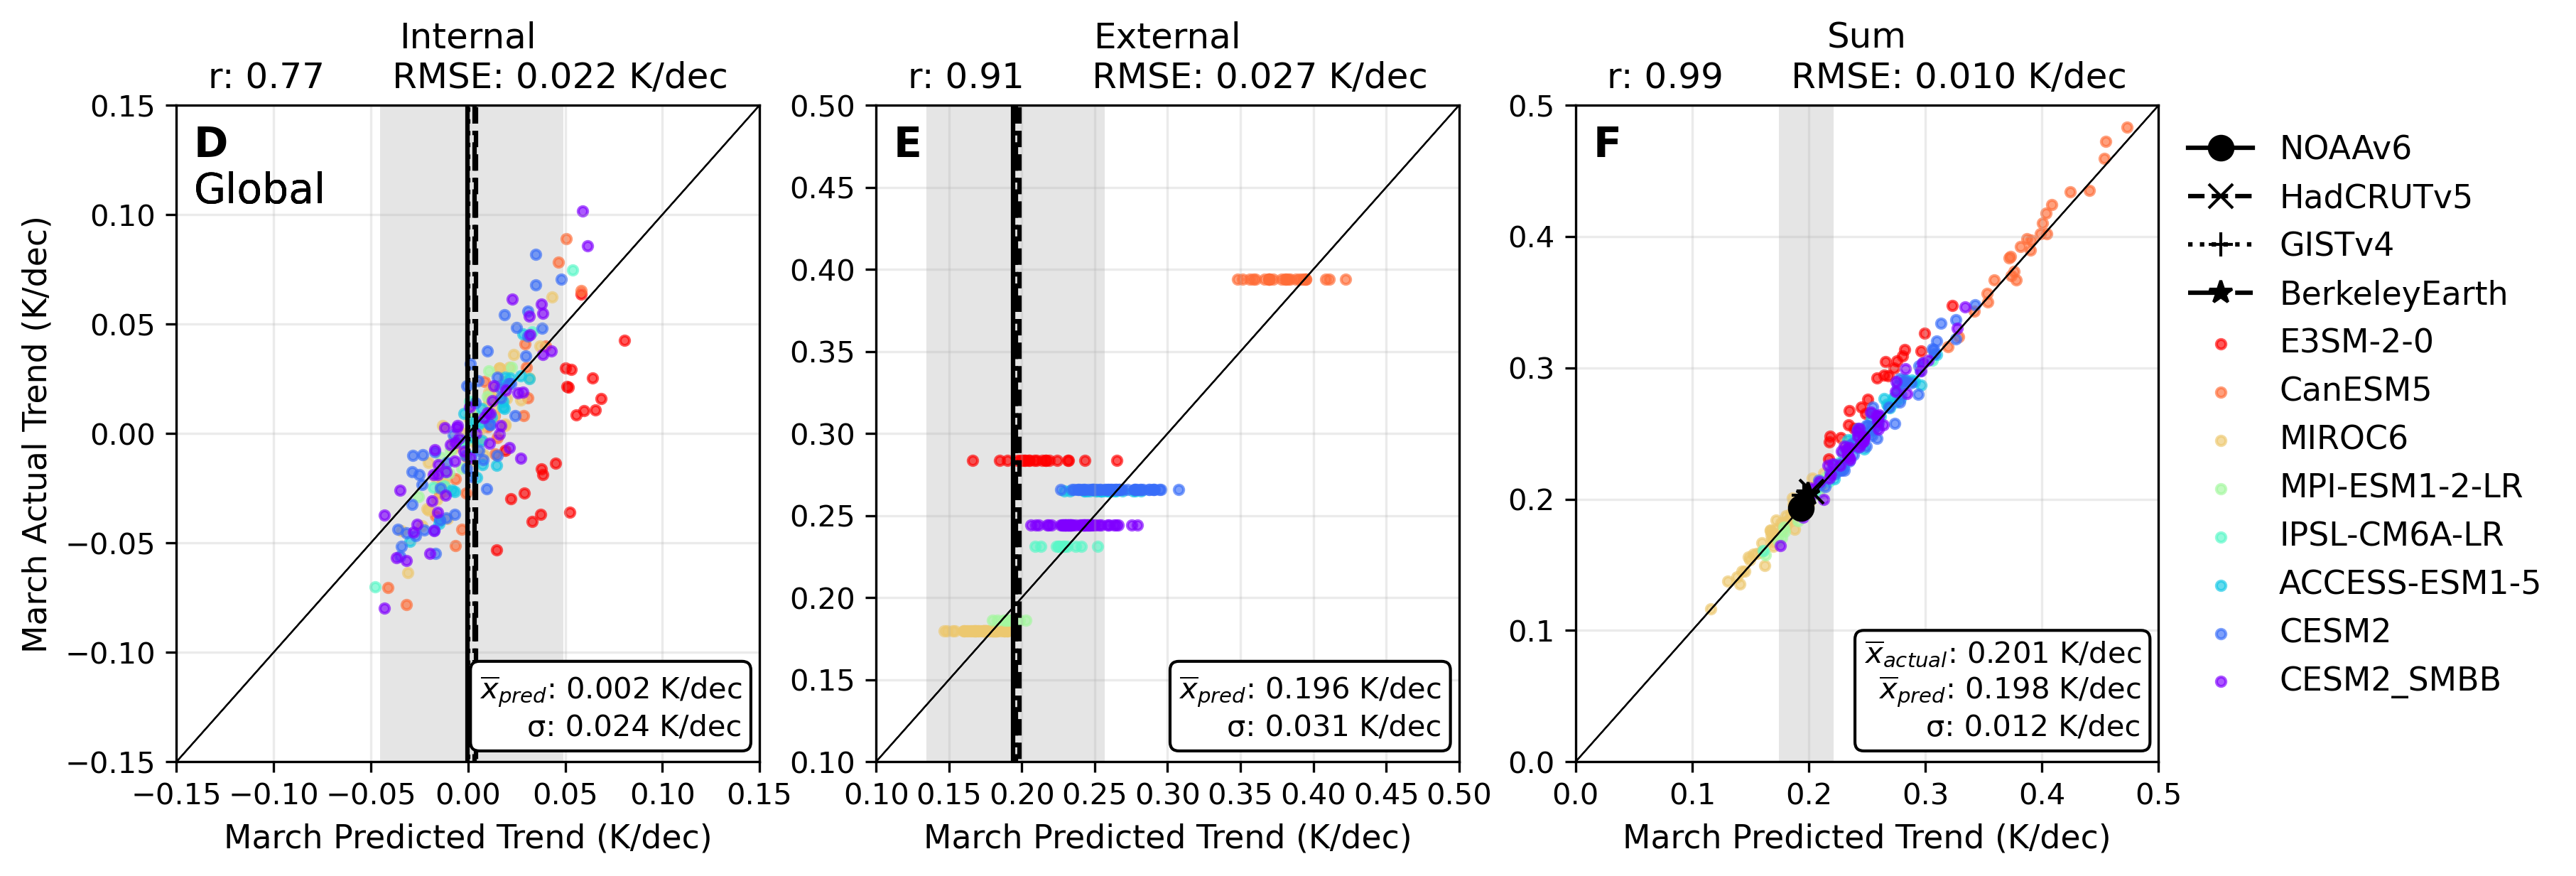

In [27]:
titles = ['Internal', 'External', 'Sum']
obs_labels = ['NOAAv6', 'HadCRUTv5', 'GISTv4', 'BerkeleyEarth']
obs_markers = ['o', 'x', '+', '*']
linestyles = ['-', '--', ':', '-.']
colors = cm.rainbow(np.linspace(0, 1, 8))[::-1]
bbox = dict(facecolor='white', ec='black', boxstyle='round')
ticks = np.arange(-0.15, 0.151, 0.05),  np.arange(0.1, 0.51, 0.05), np.arange(0, 0.51, 0.1)
top = 0.02

obs_actual = str(np.round(np.nanmean(actual_trends_obs_means, axis=0), 3)[m])

fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=300, facecolor='white')
cv_preds_and_vals_ = cv_preds_and_vals
cv_obs_ = np.swapaxes(np.array(cv_obs), 0, 2)

new_errors = []
for error in prediction_error:
    squared_error = np.multiply(error, error)
    new_errors.append(squared_error/len(squared_error))
new_errors_all = np.concatenate(new_errors)
new_errors_sum = np.nansum(new_errors_all, 0)
new_errors_std = np.sqrt(new_errors_sum/8)

for i in range(3):
    axs[0].text(0.03, 0.9, f'{region}', fontsize=14, transform=axs[0].transAxes, va='top', ha='left')
    all_obs_spread = np.nanmean(cv_obs_[:, i, :], 1).ravel()
    obs_mean = np.nanmean(all_obs_spread)
    sigma_obs = np.nanstd(all_obs_spread)
    sigma_cnn = new_errors_std[i]
    print('Sigma_obs:', sigma_obs)
    print('Sigma_CNN:', sigma_cnn)
    sigma = np.sqrt(sigma_obs**2+sigma_cnn**2)
    axs[i].axvspan(obs_mean-2*sigma, obs_mean+2*sigma, color='grey', alpha=0.2, ec=None)
    cv_obs_set = cv_obs_[:, i, :].reshape(4, 8)
    mean = str(round(obs_mean, 3))
    std = str(round(sigma, 3))

    if i in [0, 1]:
        text = '$\overline{x}$$_{pred}$: '+mean+' K/dec\nσ: '+std+' K/dec'
        axs[i].text(0.97, 0.03, text, transform=axs[i].transAxes, fontsize=10, va='bottom', ha='right', bbox=bbox)
        for idx in range(len(cv_obs_set)):
            obs_set_all_cv = cv_obs_set[idx]
            mean_obs = np.nanmean(obs_set_all_cv)
            axs[i].plot(np.repeat(mean_obs, 3), [-5, 0.3, 5], linestyle=linestyles[idx], linewidth=1.5, color='k', label=obs_labels[idx])
    else:
        text = '$\overline{x}$$_{actual}$: '+obs_actual+' K/dec'+'\n$\overline{x}$$_{pred}$: '+mean+' K/dec\nσ: '+std+' K/dec'
        axs[i].text(0.97, 0.03, text, transform=axs[i].transAxes, fontsize=10,  va='bottom', ha='right', bbox=bbox)
        for idx in range(len(cv_obs_set)):
            obs_set_all_cv = cv_obs_set[idx]
            mean_obs = np.nanmean(obs_set_all_cv)
            axs[i].plot(mean_obs, actual_trends_obs_means[:, m][idx], linestyle=linestyles[idx], marker=obs_markers[idx], markersize=8, color='k', label=obs_labels[idx])

for model_idx, set_of_preds_and_vals in enumerate(cv_preds_and_vals_):
    Y_pred = np.array(set_of_preds_and_vals[0])
    Y_test = np.array(set_of_preds_and_vals[1])
    for i in range(3):
        axs[i].scatter(Y_pred[:, i], Y_test[:, i], color=colors[model_idx], s=10, alpha=0.65, label=model_names_spliced[model_idx])
        axs[i].axline((0, 0), slope=1, color='k', alpha=0.5, linewidth=0.5)
        axs[i].set_xticks(ticks[i])
        axs[i].set_yticks(ticks[i])
        axs[i].set_ylim(ticks[i][0], ticks[i][-1])
        axs[i].set_xlim(ticks[i][0], ticks[i][-1])

all_preds_and_vals = np.concatenate(cv_preds_and_vals_, axis=1)
labels = ['D', 'E', 'F']

for i in range(3):
    axs[i].text(0.03, 0.97, labels[i], fontsize=14, transform=axs[i].transAxes, va='top', ha='left', fontweight='bold')
    Y_pred = all_preds_and_vals[0]
    Y_test = all_preds_and_vals[1]
    MSE = np.nanmean(np.square(Y_pred[:, i]-Y_test[:, i]), 0)
    MSE_str = str(np.around(MSE, 5))
    r = stats.pearsonr(Y_pred[:, i], Y_test[:, i])[0]
    r_str = str(np.around(r, 3))
    axs[i].set_title(titles[i]+'\nr: {:.2f}'.format(round(r, 2))+'      RMSE: {:.3f} K/dec'.format(round(np.sqrt(MSE), 3)), fontsize=12)
    axs[i].set_xlabel(f'{months[m]} Predicted Trend (K/dec)', fontsize=11)
    axs[0].set_ylabel(f'{months[m]} Actual Trend (K/dec)', fontsize=11)
    axs[i].grid(alpha=0.25)
    axs[i].tick_params(axis='both', which='major', labelsize=10)
    axs[i].tick_params(axis='both', which='minor', labelsize=10)

axs[2].legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=11)
plt.savefig('./figures/'+region+'_'+months[m]+'.png', dpi=300)
plt.show()